<a href="https://colab.research.google.com/github/Bhumika421/ML-and-AI/blob/main/2431475_BhumikaShrestha_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Racist / Sexist Tweet Classification

### Binary Text Classification | RNN · LSTM · BiLSTM + FastText

In [ ]:
# ── Imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

!pip install contractions --quiet
import contractions

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Bidirectional, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

!pip install gensim --quiet
import gensim.downloader as api

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

print('TensorFlow:', tf.__version__)
print('All imports successful.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.5 MB/s eta 0:00:00
TensorFlow: 2.20.0
All imports successful.


## 2 · Load Dataset

In [ ]:
# ── Mount Google Drive ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── File paths ───────────────────────────────────────────────────
TRAIN_FILE = '/content/drive/MyDrive/AI AND ML/Data/7. Racist Sexist or Not Dataset/train_racisit.csv'
TEST_FILE  = '/content/drive/MyDrive/AI AND ML/Data/7. Racist Sexist or Not Dataset/test_racisit.csv'

train_data = pd.read_csv(TRAIN_FILE)
test_data  = pd.read_csv(TEST_FILE)

print('Train shape:', train_data.shape)
print('Test  shape:', test_data.shape)
print()
print(train_data.head())


Train shape: (31962, 3)
Test  shape: (17197, 2)

   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation


In [ ]:
print('Columns     :', train_data.columns.tolist())
print('Null values :\n', train_data.isnull().sum())
print()
print('Label distribution:')
print(train_data['label'].value_counts())
print()
print('Label balance (%):')
print(train_data['label'].value_counts(normalize=True).mul(100).round(2))


Columns     : ['id', 'label', 'tweet']
Null values :
 id       0
label    0
tweet    0
dtype: int64

Label distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Label balance (%):
label
0    92.99
1     7.01
Name: proportion, dtype: float64


## 3 · Exploratory Data Analysis

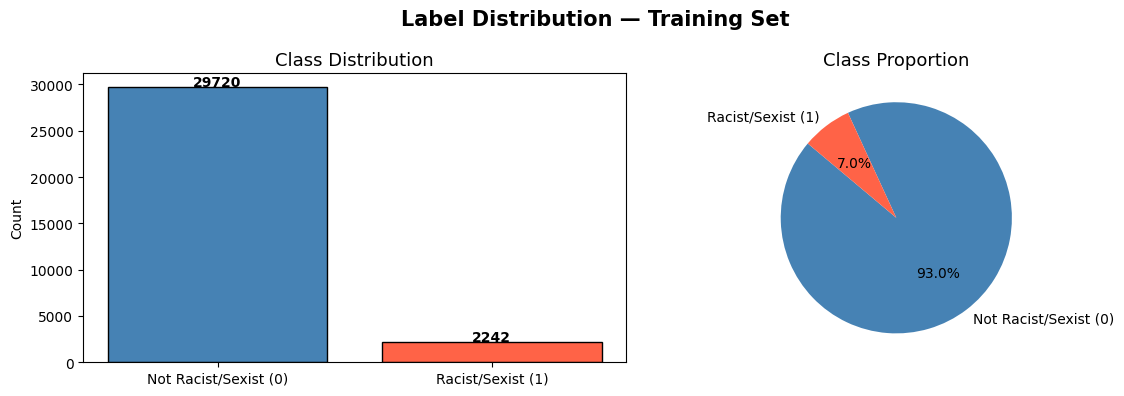

Imbalance ratio: 13.3 : 1


In [ ]:
# ── 3.1 Class distribution ───────────────────────────────────────
label_freq  = train_data['label'].value_counts()
label_map   = {0: 'Not Racist/Sexist (0)', 1: 'Racist/Sexist (1)'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar([label_map[l] for l in label_freq.index], label_freq.values,
        color=['steelblue', 'tomato'], edgecolor='black')
ax1.set_title('Class Distribution', fontsize=13)
ax1.set_ylabel('Count')
for i, v in enumerate(label_freq.values):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

ax2.pie(label_freq.values,
        labels=[label_map[l] for l in label_freq.index],
        autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=140)
ax2.set_title('Class Proportion', fontsize=13)

plt.suptitle('Label Distribution — Training Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Imbalance ratio: {label_freq[0] / label_freq[1]:.1f} : 1')


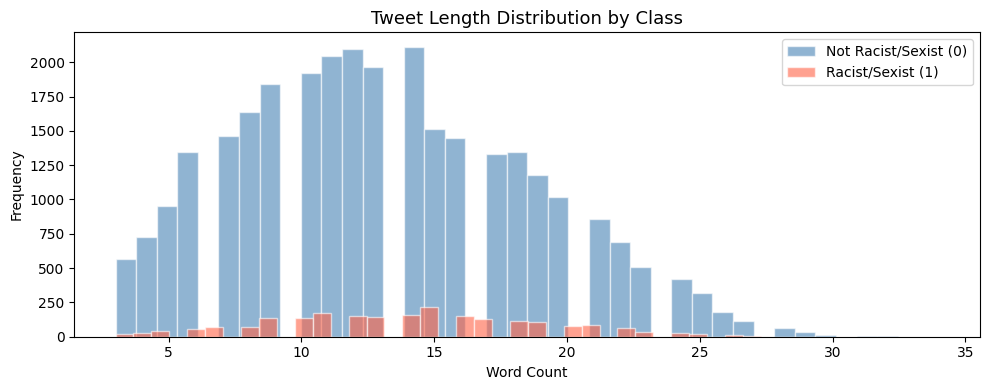

         count       mean       std  min   25%   50%   75%   max
label                                                           
0      29720.0  13.091252  5.510082  3.0   9.0  13.0  17.0  34.0
1       2242.0  14.053078  4.950747  3.0  10.0  14.0  17.0  30.0


In [ ]:
# ── 3.2 Tweet length distribution ───────────────────────────────
train_data['word_count'] = train_data['tweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
for lbl, col in zip([0, 1], ['steelblue', 'tomato']):
    subset = train_data[train_data['label'] == lbl]['word_count']
    plt.hist(subset, bins=40, alpha=0.6, color=col,
             label=label_map[lbl], edgecolor='white')
plt.title('Tweet Length Distribution by Class', fontsize=13)
plt.xlabel('Word Count'); plt.ylabel('Frequency'); plt.legend()
plt.tight_layout(); plt.show()

print(train_data.groupby('label')['word_count'].describe())


## 4 · Text Preprocessing

In [ ]:
stop_word_set = set(stopwords.words('english'))
word_lemmatizer = WordNetLemmatizer()

def preprocess_tweet(raw_text):
    """Clean a single tweet: lowercase, expand contractions, remove noise."""
    text = str(raw_text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\brt\b', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [word_lemmatizer.lemmatize(w)
              for w in text.split()
              if w not in stop_word_set and len(w) > 1]
    return ' '.join(tokens)

train_data['clean_text'] = train_data['tweet'].apply(preprocess_tweet)
test_data['clean_text']  = test_data['tweet'].apply(preprocess_tweet)

pd.set_option('display.max_colwidth', 120)
print('Before vs After cleaning:')
train_data[['tweet', 'clean_text']].sample(5, random_state=1)

Before vs After cleaning:


,tweet,clean_text
266,i'll probably be 30 by the time @user comes back home #ugh,probably time come back home ugh
20460,just finished recoding my audition for abc dicovers. #abcdiscovers #abc #actorslife #sagaftra,finished recoding audition abc dicovers abcdiscovers abc actorslife sagaftra
18133,"this will be dustin's bihday present, bihday dj,",dustins bihday present bihday dj
15417,"this is my ""do i really have to go to work face""!!!! #work #face #itsfriday #wanttosleep",really go work face work face itsfriday wanttosleep
3077,eat the all #muslm,eat muslm


## 5 · Post-Cleaning Visualisations

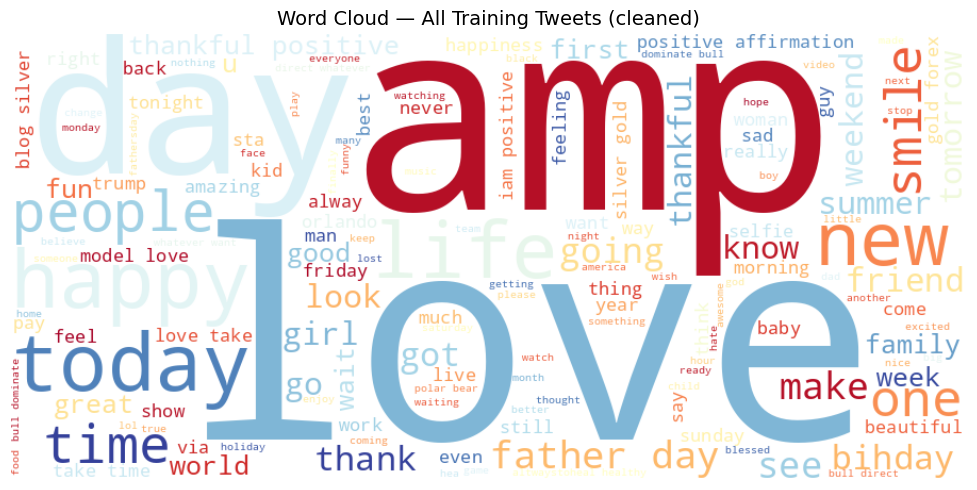

In [ ]:
# ── 5.1 Word cloud — all tweets ──────────────────────────────────
combined_text = ' '.join(train_data['clean_text'])

wcloud = WordCloud(width=900, height=420, background_color='white',
                   colormap='RdYlBu', max_words=150).generate(combined_text)

plt.figure(figsize=(13, 5))
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Training Tweets (cleaned)', fontsize=14)
plt.tight_layout(); plt.show()


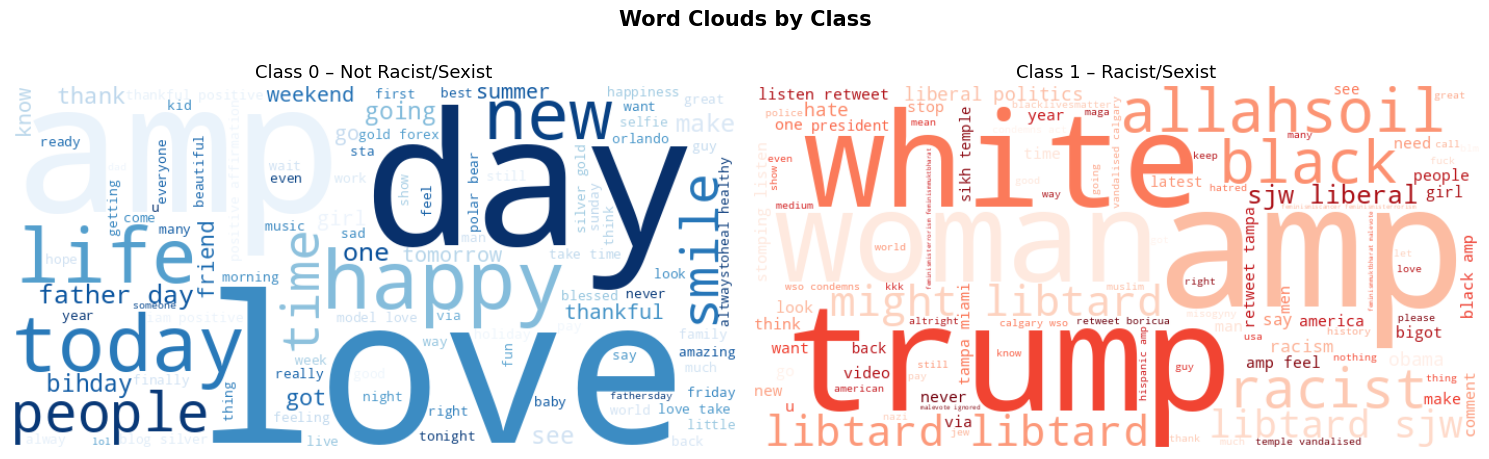

In [ ]:
# ── 5.2 Per-class word clouds ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, lbl, cmap, ttl in zip(axes, [0, 1], ['Blues', 'Reds'],
                               ['Class 0 – Not Racist/Sexist', 'Class 1 – Racist/Sexist']):
    txt = ' '.join(train_data[train_data['label'] == lbl]['clean_text'])
    wc  = WordCloud(width=700, height=350, background_color='white',
                    colormap=cmap, max_words=100).generate(txt)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(ttl, fontsize=13)
plt.suptitle('Word Clouds by Class', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


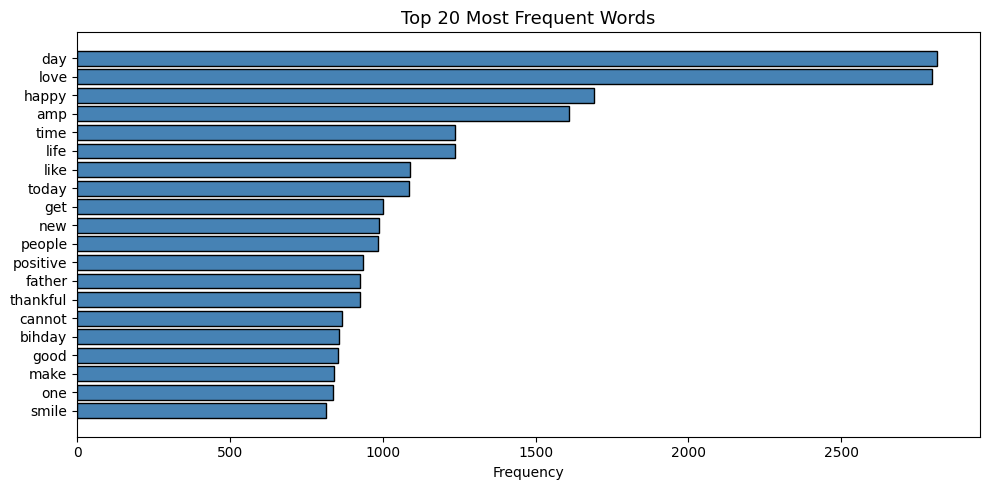

Top 20: [('day', 2813), ('love', 2796), ('happy', 1691), ('amp', 1608), ('time', 1235), ('life', 1235), ('like', 1088), ('today', 1086), ('get', 1000), ('new', 988), ('people', 985), ('positive', 935), ('father', 925), ('thankful', 925), ('cannot', 867), ('bihday', 856), ('good', 853), ('make', 842), ('one', 837), ('smile', 813)]


In [ ]:
# ── 5.3 Top-20 words ─────────────────────────────────────────────
word_list    = combined_text.split()
top_20_words = Counter(word_list).most_common(20)
wds, freqs   = zip(*top_20_words)

plt.figure(figsize=(10, 5))
plt.barh(wds[::-1], freqs[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words', fontsize=13)
plt.tight_layout(); plt.show()
print('Top 20:', top_20_words)


## 6 · Prepare Features & Labels

In [ ]:
features = train_data['clean_text'].values
targets  = train_data['label'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    features, targets, test_size=0.2, random_state=42, stratify=targets)

print(f'Train samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')
print(f'Train labels  : {Counter(y_train)}')
print(f'Test  labels  : {Counter(y_test)}')


Train samples : 25569
Test  samples : 6393
Train labels  : Counter({np.int64(0): 23775, np.int64(1): 1794})
Test  labels  : Counter({np.int64(0): 5945, np.int64(1): 448})


## 7 · Tokenisation & Padding

In [ ]:
NUM_WORDS  = 10000
UNK_TOKEN  = '<OOV>'

tok = Tokenizer(num_words=NUM_WORDS, oov_token=UNK_TOKEN,
                filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tok.fit_on_texts(X_train)

train_sequences = tok.texts_to_sequences(X_train)
test_sequences  = tok.texts_to_sequences(X_test)

lengths     = [len(s) for s in train_sequences]
MAX_LEN     = int(np.percentile(lengths, 95))
coverage_pct = sum(1 for s in lengths if s <= MAX_LEN) / len(lengths)

print(f'Vocab size : {len(tok.word_index):,}')
print(f'Max length : {MAX_LEN} tokens  ({coverage_pct:.1%} coverage)')

X_train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_padded : {X_train_padded.shape}')
print(f'X_test_padded  : {X_test_padded.shape}')


Vocab size : 32,104
Max length : 13 tokens  (97.1% coverage)
X_train_padded : (25569, 13)
X_test_padded  : (6393, 13)


## 8 · Handle Class Imbalance

Before resampling: Counter({np.int64(0): 23775, np.int64(1): 1794})
After  resampling: Counter({np.int64(0): 23775, np.int64(1): 23775})
Balanced size: 47,550


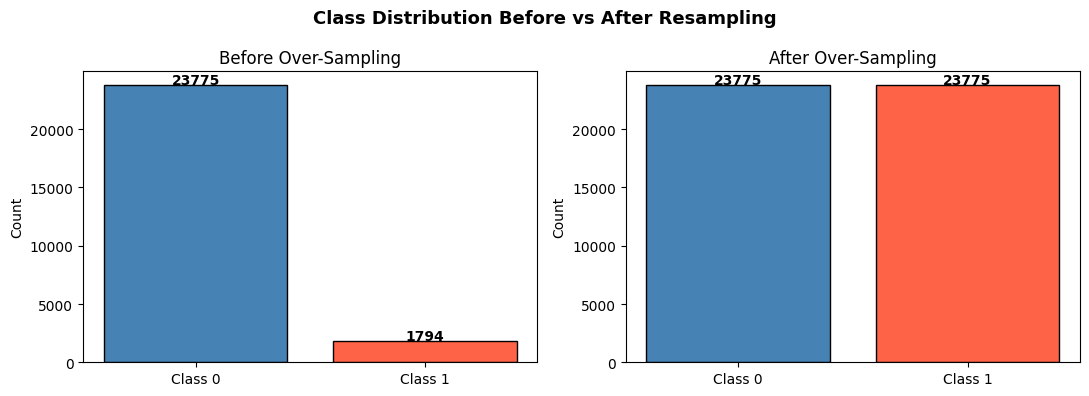

In [ ]:
print('Before resampling:', Counter(y_train))

oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_balanced, y_balanced = oversampler.fit_resample(X_train_padded, y_train)

print('After  resampling:', Counter(y_balanced))
print(f'Balanced size: {len(X_balanced):,}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax, cnt, ttl in zip([ax1, ax2],
                         [Counter(y_train), Counter(y_balanced)],
                         ['Before Over-Sampling', 'After Over-Sampling']):
    ax.bar(['Class 0', 'Class 1'], [cnt[0], cnt[1]],
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(ttl, fontsize=12); ax.set_ylabel('Count')
    for i, v in enumerate([cnt[0], cnt[1]]):
        ax.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.suptitle('Class Distribution Before vs After Resampling', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9 · Load Pre-trained FastText Embeddings

In [ ]:
print('Loading FastText embeddings …')
ft_model   = api.load('fasttext-wiki-news-subwords-300')
EMBED_SIZE = 300
print(f'Loaded. Vocab: {len(ft_model.key_to_index):,}')


Loading FastText embeddings …
[==================================================] 100.0% 958.5/958.4MB downloaded
Loaded. Vocab: 999,999


In [ ]:
embed_matrix = np.zeros((NUM_WORDS, EMBED_SIZE))
matched = 0
for word, idx in tok.word_index.items():
    if idx < NUM_WORDS and word in ft_model:
        embed_matrix[idx] = ft_model[word]
        matched += 1

pct = matched / min(NUM_WORDS, len(tok.word_index))
print(f'FastText coverage: {matched:,} / {min(NUM_WORDS, len(tok.word_index)):,}  ({pct:.1%})')


FastText coverage: 7,921 / 10,000  (79.2%)


## 10 · Model Training
### Global Config & Helpers

In [ ]:
SMALL_EMBED = 128
BATCH       = 64
EPOCHS      = 30
timer_log   = {}

# Stratified validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for tr_idx, val_idx in sss.split(X_balanced, y_balanced):
    X_tr, X_val = X_balanced[tr_idx], X_balanced[val_idx]
    y_tr, y_val = y_balanced[tr_idx], y_balanced[val_idx]

print(f'Train: {X_tr.shape}  |  Val: {X_val.shape}')


Train: (38040, 13)  |  Val: (9510, 13)


In [ ]:
def show_history(hist, name):
    """Plot accuracy and loss curves."""
    ep = range(1, len(hist.history['accuracy']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(ep, hist.history['accuracy'],     'bo-', label='Train Accuracy')
    plt.plot(ep, hist.history['val_accuracy'], 'ro-', label='Val   Accuracy')
    plt.title(f'{name} — Accuracy', fontsize=12)
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(ep, hist.history['loss'],     'bo-', label='Train Loss')
    plt.plot(ep, hist.history['val_loss'], 'ro-', label='Val   Loss')
    plt.title(f'{name} — Loss', fontsize=12)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    plt.tight_layout(); plt.show()


def assess_model(mdl, X, y, name, thresh=0.5):
    """Evaluate model: accuracy, report, confusion matrix."""
    loss_val, acc_val = mdl.evaluate(X, y, verbose=0)
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'Accuracy : {acc_val:.4f}  |  Loss : {loss_val:.4f}')

    probs = mdl.predict(X, verbose=0).flatten()
    preds = (probs >= thresh).astype(int)

    print(f'\nClassification Report:')
    print(classification_report(y, preds,
          target_names=['Not Racist/Sexist', 'Racist/Sexist'], digits=4))

    cm = confusion_matrix(y, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Not Racist/Sexist', 'Racist/Sexist']).plot(
        cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    plt.tight_layout(); plt.show()
    return acc_val, loss_val

print('Config and helpers ready.')

Config and helpers ready.


### Model 1 · Simple RNN

In [ ]:
tf.random.set_seed(42)

rnn_model = Sequential(name='SimpleRNN', layers=[
    Embedding(input_dim=NUM_WORDS, output_dim=SMALL_EMBED, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es1 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

t0 = time.time()
hist1 = rnn_model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH,
                      validation_data=(X_val, y_val), callbacks=[es1], verbose=1)
timer_log['Model 1 – Simple RNN'] = time.time() - t0
print(f'Training time: {timer_log["Model 1 – Simple RNN"]:.1f}s')


Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9346 - loss: 0.1555 - val_accuracy: 0.9848 - val_loss: 0.0443
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9921 - loss: 0.0238 - val_accuracy: 0.9864 - val_loss: 0.0507
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9768 - val_loss: 0.0811
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 0.9877 - val_loss: 0.0446
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Training time: 23.2s


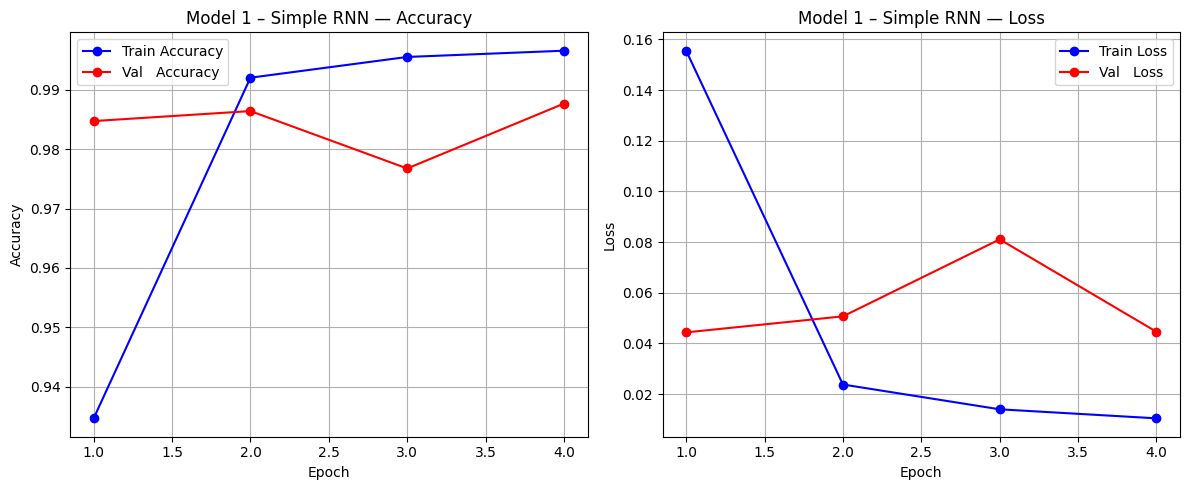


  Model 1 – Simple RNN
Accuracy : 0.9479  |  Loss : 0.1824

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist     0.9697    0.9744    0.9721      5945
    Racist/Sexist     0.6372    0.5960    0.6159       448

         accuracy                         0.9479      6393
        macro avg     0.8035    0.7852    0.7940      6393
     weighted avg     0.9464    0.9479    0.9471      6393



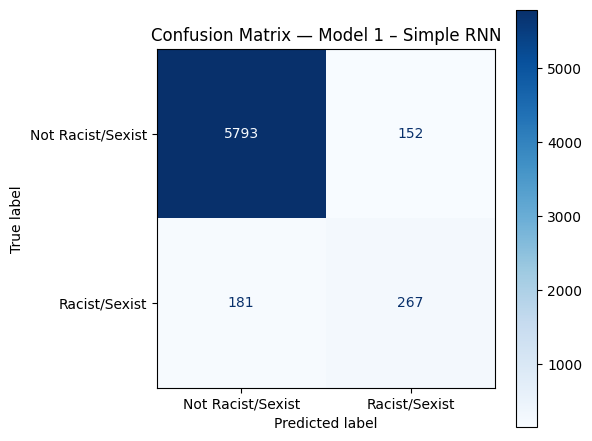

In [ ]:
show_history(hist1, 'Model 1 – Simple RNN')
acc1, loss1 = assess_model(rnn_model, X_test_padded, y_test, 'Model 1 – Simple RNN')


### Model 2 · LSTM with Trainable Embeddings

In [ ]:
tf.random.set_seed(42)

lstm_model = Sequential(name='LSTM_TrainableEmb', layers=[
    Embedding(input_dim=NUM_WORDS, output_dim=SMALL_EMBED, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1,  activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy',
                   optimizer=Adam(learning_rate=0.0005),
                   metrics=['accuracy'])
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_TrainableEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es2  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr2  = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)

t0 = time.time()
hist2 = lstm_model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH,
                       validation_data=(X_val, y_val), callbacks=[es2, lr2], verbose=1)
timer_log['Model 2 – LSTM'] = time.time() - t0
print(f'Training time: {timer_log["Model 2 – LSTM"]:.1f}s')


Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9166 - loss: 0.2018 - val_accuracy: 0.9731 - val_loss: 0.0835 - learning_rate: 5.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9817 - loss: 0.0560 - val_accuracy: 0.9697 - val_loss: 0.1014 - learning_rate: 5.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9881 - loss: 0.0362 - val_accuracy: 0.9661 - val_loss: 0.1251 - learning_rate: 5.0000e-04
Epoch 4/30
592/595 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9894 - loss: 0.0291
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
595/595 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9899 - loss: 0.0271 - val_accuracy: 0.9566 - val_loss: 0.1710 - learning_rate: 5.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9945 - loss: 0.0152 - val_accuracy: 0.9800 - val_loss: 0.1049 - learning_rate: 1.5000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.

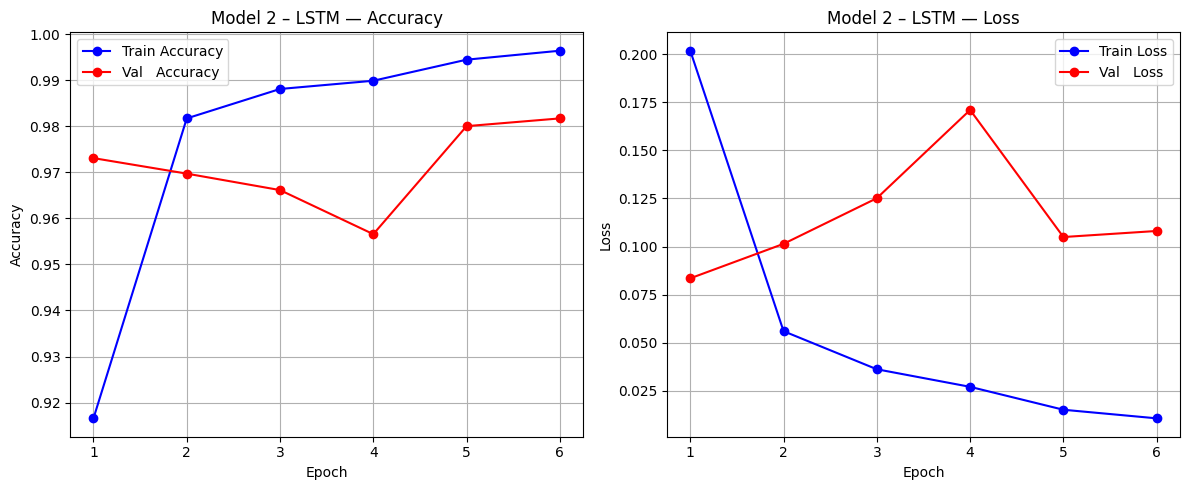


  Model 2 – LSTM
Accuracy : 0.9467  |  Loss : 0.1832

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist     0.9791    0.9632    0.9711      5945
    Racist/Sexist     0.5982    0.7277    0.6566       448

         accuracy                         0.9467      6393
        macro avg     0.7887    0.8454    0.8138      6393
     weighted avg     0.9524    0.9467    0.9490      6393



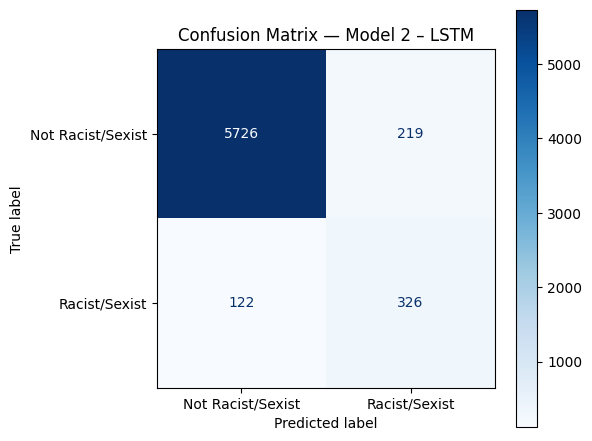

In [ ]:
show_history(hist2, 'Model 2 – LSTM')
acc2, loss2 = assess_model(lstm_model, X_test_padded, y_test, 'Model 2 – LSTM')


### Model 3 · Bidirectional LSTM + FastText Embeddings

In [ ]:
tf.random.set_seed(42)

bilstm_model = Sequential(name='BiLSTM_FastText', layers=[
    Embedding(input_dim=NUM_WORDS, output_dim=EMBED_SIZE,
              weights=[embed_matrix], input_length=MAX_LEN, trainable=False),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(loss='binary_crossentropy',
                     optimizer=Adam(learning_rate=0.0005),
                     metrics=['accuracy'])
bilstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_FastText"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
es3 = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
lr3 = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)

cw_array = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cw_dict  = dict(enumerate(cw_array))
print('Class weights:', cw_dict)

t0 = time.time()
hist3 = bilstm_model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH,
                         validation_data=(X_val, y_val),
                         callbacks=[es3, lr3], class_weight=cw_dict, verbose=1)
timer_log['Model 3 – BiLSTM + FastText'] = time.time() - t0
print(f'Training time: {timer_log["Model 3 – BiLSTM + FastText"]:.1f}s')


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8472 - loss: 0.3586 - val_accuracy: 0.8672 - val_loss: 0.3039 - learning_rate: 5.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8844 - loss: 0.2723 - val_accuracy: 0.8871 - val_loss: 0.2572 - learning_rate: 5.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9034 - loss: 0.2288 - val_accuracy: 0.9017 - val_loss: 0.2248 - learning_rate: 5.0000e-04
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9206 - loss: 0.1946 - val_accuracy: 0.9045 - val_loss: 0.2187 - learning_rate: 5.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9316 - loss: 0.1703 - val_accuracy: 0.9313 - val_loss: 0.1758 - learning_rate: 5.0000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9440 - loss: 0.1450 - val_accuracy: 0.9414 - val_loss: 0.1534 - learning_rate: 5.0000e-04
Epoc

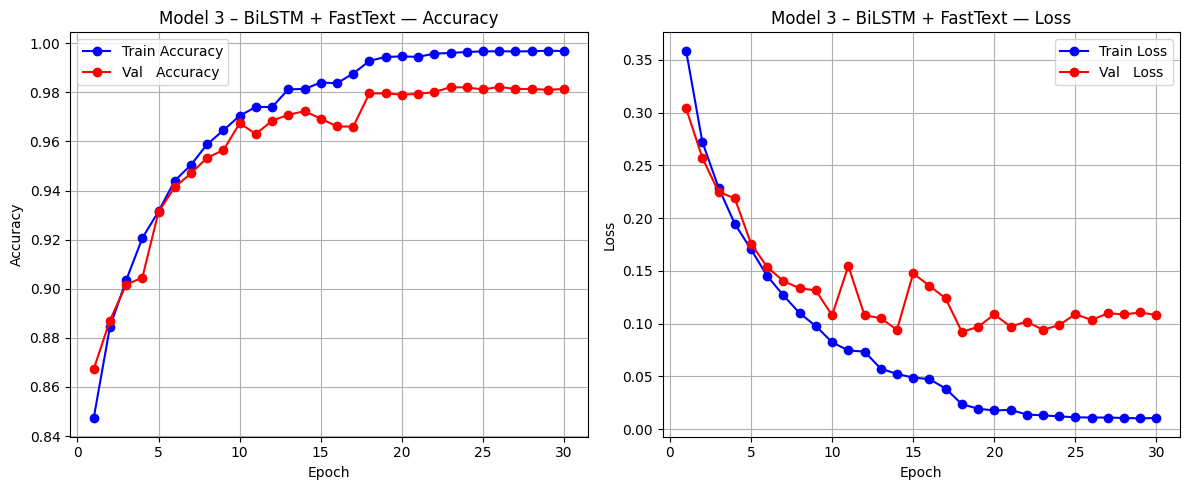


  Model 3 – BiLSTM + FastText
Accuracy : 0.9482  |  Loss : 0.6659

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist     0.9729    0.9714    0.9721      5945
    Racist/Sexist     0.6280    0.6406    0.6343       448

         accuracy                         0.9482      6393
        macro avg     0.8004    0.8060    0.8032      6393
     weighted avg     0.9487    0.9482    0.9485      6393



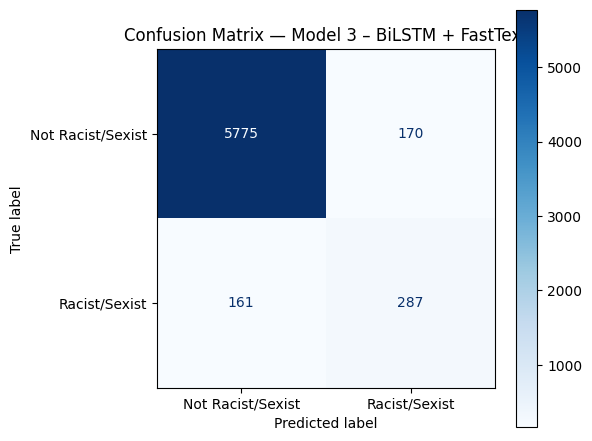

In [ ]:
show_history(hist3, 'Model 3 – BiLSTM + FastText')
acc3, loss3 = assess_model(bilstm_model, X_test_padded, y_test, 'Model 3 – BiLSTM + FastText')


## 11 · Final Model Comparison

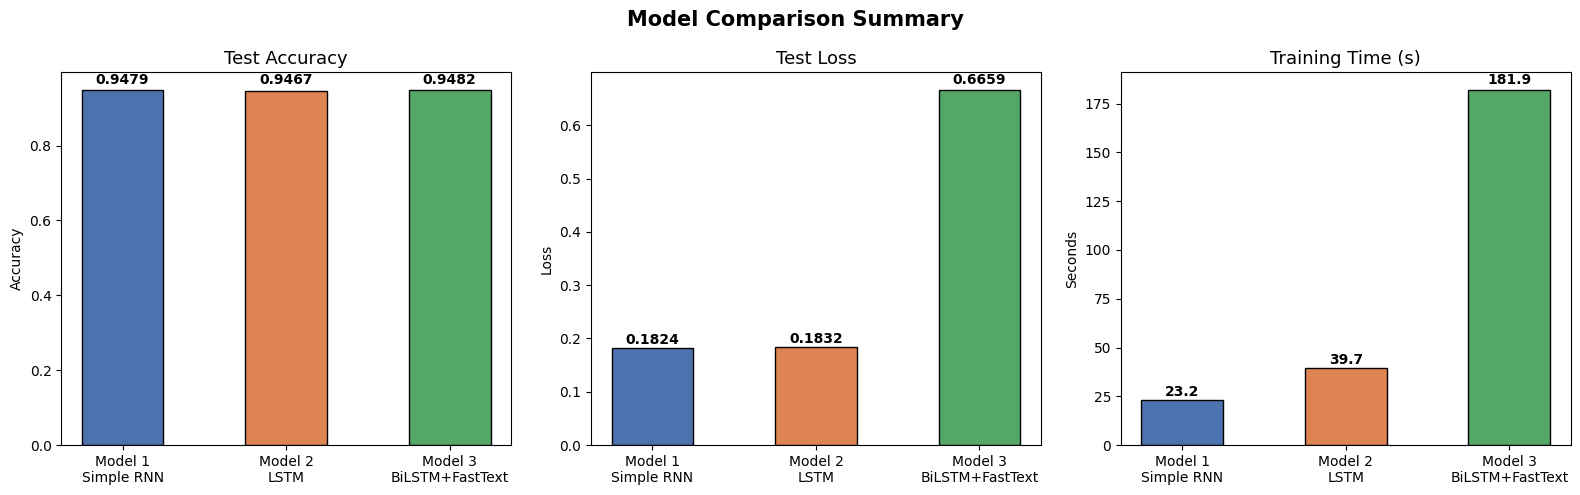


── Final Summary ──────────────────────────────────
Model 1 – Simple RNN                 Acc=0.9479  Loss=0.1824  Time=0.39 min
Model 2 – LSTM                       Acc=0.9467  Loss=0.1832  Time=0.66 min
Model 3 – BiLSTM + FastText          Acc=0.9482  Loss=0.6659  Time=3.03 min


In [ ]:
model_labels = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nBiLSTM+FastText']
acc_vals     = [acc1, acc2, acc3]
loss_vals    = [loss1, loss2, loss3]
time_vals    = list(timer_log.values())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#4C72B0', '#DD8452', '#55A868']

for ax, vals, ttl, ylbl, fmt in zip(
        axes,
        [acc_vals, loss_vals, time_vals],
        ['Test Accuracy', 'Test Loss', 'Training Time (s)'],
        ['Accuracy', 'Loss', 'Seconds'],
        ['.4f', '.4f', '.1f']):
    bars = ax.bar(model_labels, vals, color=palette, edgecolor='black', width=0.5)
    ax.set_title(ttl, fontsize=13); ax.set_ylabel(ylbl)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.01,
                f'{v:{fmt}}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Model Comparison Summary', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n── Final Summary ──────────────────────────────────')
for name, acc, loss, t in zip(timer_log.keys(), acc_vals, loss_vals, time_vals):
    print(f'{name:<35}  Acc={acc:.4f}  Loss={loss:.4f}  Time={t/60:.2f} min')


### Model 1 vs Model 2 vs Model 3 — Training Curve Comparison

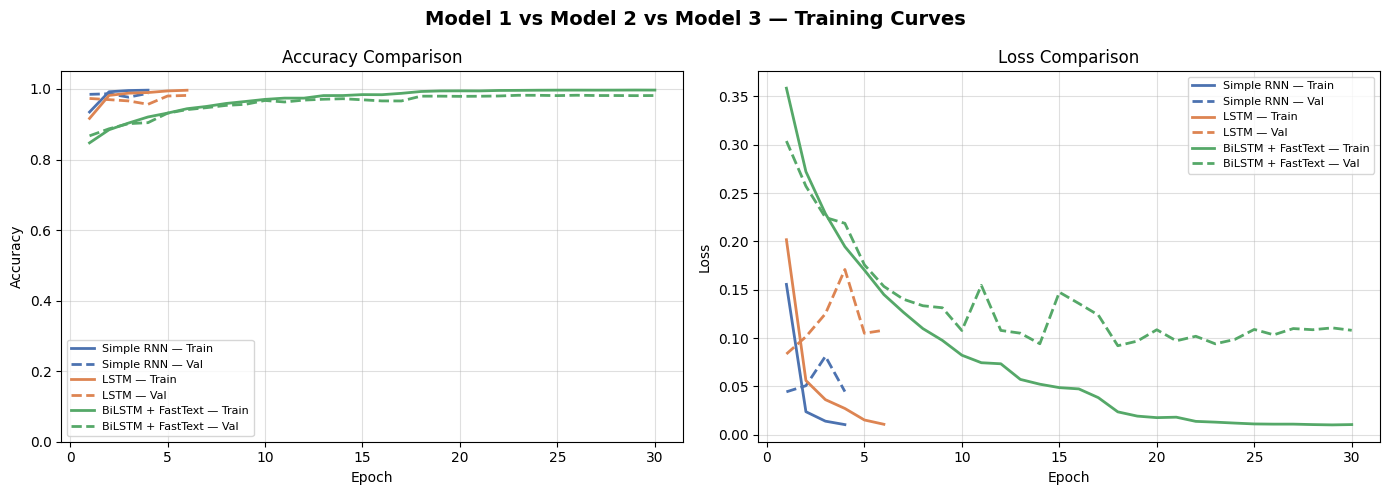

Observations:
  Simple RNN  best val acc : 0.9877
  LSTM        best val acc : 0.9817
  BiLSTM+FT   best val acc : 0.9822
BiLSTM + FastText typically achieves best accuracy due to pretrained embeddings.
LSTM outperforms RNN due to its ability to capture long-range dependencies.


In [ ]:
# ── Side-by-side training curve comparison: RNN vs LSTM vs BiLSTM ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 1 vs Model 2 vs Model 3 — Training Curves', fontsize=14, fontweight='bold')

colours  = ['#4C72B0', '#DD8452', '#55A868']
names    = ['Simple RNN', 'LSTM', 'BiLSTM + FastText']
hists    = [hist1, hist2, hist3]

# Accuracy plot
ax = axes[0]
for h, name, col in zip(hists, names, colours):
    ep = range(1, len(h.history['accuracy']) + 1)
    ax.plot(ep, h.history['accuracy'],     color=col, lw=2,       label=f'{name} — Train')
    ax.plot(ep, h.history['val_accuracy'], color=col, lw=2, ls='--', label=f'{name} — Val')
ax.set_title('Accuracy Comparison'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

# Loss plot
ax = axes[1]
for h, name, col in zip(hists, names, colours):
    ep = range(1, len(h.history['loss']) + 1)
    ax.plot(ep, h.history['loss'],     color=col, lw=2,       label=f'{name} — Train')
    ax.plot(ep, h.history['val_loss'], color=col, lw=2, ls='--', label=f'{name} — Val')
ax.set_title('Loss Comparison'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print('Observations:')
print(f'  Simple RNN  best val acc : {max(hist1.history["val_accuracy"]):.4f}')
print(f'  LSTM        best val acc : {max(hist2.history["val_accuracy"]):.4f}')
print(f'  BiLSTM+FT   best val acc : {max(hist3.history["val_accuracy"]):.4f}')
print('BiLSTM + FastText typically achieves best accuracy due to pretrained embeddings.')
print('LSTM outperforms RNN due to its ability to capture long-range dependencies.')


## 12 · Error Analysis

In [ ]:
# Show misclassified examples
probs_all = bilstm_model.predict(X_test_padded, verbose=0).flatten()
preds_all = (probs_all >= 0.5).astype(int)

wrong_idx = np.where(preds_all != y_test)[0]
print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)}')
print()

# Show 3 examples
reverse_index = {v: k for k, v in tok.word_index.items()}
for i, idx in enumerate(wrong_idx[:3]):
    tokens = [reverse_index.get(t, '') for t in X_test_padded[idx] if t != 0]
    print(f'Example {i+1}:')
    print(f'  Text      : {" ".join(tokens[:20])}')
    print(f'  True label: {y_test[idx]}')
    print(f'  Predicted : {preds_all[idx]}')
    print(f'  Confidence: {probs_all[idx]:.3f}')
    print()


Total misclassified: 331 / 6393

Example 1:
  Text      : beware snowball effect <OOV> pa
  True label: 1
  Predicted : 0
  Confidence: 0.000

Example 2:
  Text      : black <OOV> wooden picture <OOV> <OOV> wooden giftideas horse <OOV> <OOV>
  True label: 0
  Predicted : 1
  Confidence: 0.998

Example 3:
  Text      : immature trying make fool <OOV> immature moron
  True label: 1
  Predicted : 0
  Confidence: 0.000



## 13 · Predict on Test Set

In [ ]:
test_seqs  = tok.texts_to_sequences(test_data['clean_text'].values)
test_pads  = pad_sequences(test_seqs, maxlen=MAX_LEN, padding='post', truncating='post')

test_probs  = bilstm_model.predict(test_pads, verbose=0).flatten()
test_preds  = (test_probs >= 0.5).astype(int)

submission_df = pd.DataFrame({'id': test_data['id'], 'label': test_preds})
submission_df.to_csv('submission_predictions.csv', index=False)

print('Predictions saved.')
print(f'Distribution: {Counter(test_preds)}')
submission_df.head(10)


Predictions saved.
Distribution: Counter({np.int64(0): 15889, np.int64(1): 1308})


,id,label
0,31963,0
1,31964,0
2,31965,0
3,31966,0
4,31967,0
5,31968,0
6,31969,0
7,31970,0
8,31971,0
9,31972,0


## 14 · Gradio Demo

In [ ]:
!pip install gradio --quiet


In [ ]:
import gradio as gr

LABEL_MAP = {0: ' Not Racist / Sexist', 1: '  Racist / Sexist'}

def predict_tweet(input_text):
    """Clean, tokenise, pad and classify a tweet."""
    cleaned = preprocess_tweet(input_text)
    seq     = tok.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    conf    = float(bilstm_model.predict(padded, verbose=0)[0][0])
    cls     = int(conf >= 0.5)
    return f"Prediction  : {LABEL_MAP[cls]}\nConfidence  : {conf*100:.1f}% (racist/sexist)"

demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder='Enter a tweet …', label='Tweet'),
    outputs=gr.Textbox(label='Result'),
    title='🔍 Racist / Sexist Tweet Classifier',
    description='BiLSTM + FastText. Enter a tweet to classify.',
    examples=[
        ['I love spending time with my family #weekend'],
        ['Women should stay in the kitchen and not in the workplace'],
        ['Great game tonight! #basketball #sports']
    ],
    theme='soft'
)
demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>